**Checking for duplicated images**

As the images were collected from many different sources, some of which where data collections themself, we think its nessecary to test for duplications.
The assumption here: If the descriptive statistical data of two images are exactly the same, it is very likely that the images are the same. Hence, I will first compare descriptive statistical data of the images with each other. In case of duplicate suspicion, I will compare the actual images.


In [ ]:
# Importing librarys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
%matplotlib inline
from glob import glob  # is used for pattern matching and filename expansion.
import sys
print(sys.executable)
import cv2
import os
import re
from scipy.stats import skew, kurtosis


In [1]:
### ---- Importing the dataset from kaggle --- ###

# Install kaggle
! pip install kaggle

# Monut google drive in colab
from google.colab import drive
drive.mount('/content/drive')

# make a new folder in the root directory
! mkdir ~/.kaggle

# Copy the kaggle-json-file (Token) into the .kaggle-folder
! cp /content/drive/MyDrive/Kaggle_API/kaggle.json ~/.kaggle/

# Change file permission
! chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset
! kaggle datasets download tawsifurrahman/covid19-radiography-database

! unzip covid19-radiography-database.zip

Streaming output truncated to the last 5000 lines.
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7921.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7922.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7923.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7924.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7925.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7926.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7927.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7928.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7929.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-793.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7930.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7931.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7932.png  
 

In [6]:
### ---- Generating list of file names --- ###

# Generating lists containing all file paths for each class
cxr_covid = glob('/content/COVID-19_Radiography_Dataset/COVID/images/*.png')
cxr_lung_opacity = glob('/content/COVID-19_Radiography_Dataset/Lung_Opacity/images/*.png')
cxr_normal = glob('/content/COVID-19_Radiography_Dataset/Normal/images/*.png')
cxr_viral_pneumonia = glob('/content/COVID-19_Radiography_Dataset/Viral Pneumonia/images/*.png')

# Concatenating all file paths into a single list
cxr_all = cxr_covid + cxr_lung_opacity + cxr_normal + cxr_viral_pneumonia

# Check the content and the length of the resulting list (Expected: list of file paths, a length of 21165 images)
print(cxr_all, '\n',len(cxr_all))

['/content/COVID-19_Radiography_Dataset/COVID/images/COVID-2243.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-1725.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-774.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-514.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-2238.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-3602.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-397.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-597.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-2971.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-1455.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-438.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-1951.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-343.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-1170.png', '/content/COVID-19_Radiography_Dataset/

In [7]:
### ---- Retrieving descriptive statistics (adapted from Tanja's code) ---- ###

# Function to retrieve statistics
def get_statistics(img):
    # Convert to float
    img = img.astype('float64')

    # Convert from 1D to 2D array
    flat_img = img.flatten()

    # Calculate statistics
    count = len(flat_img)
    meani = np.mean(flat_img)
    std = np.std(flat_img)
    mini = np.min(flat_img)
    maxi = np.max(flat_img)
    med = np.median(flat_img)
    q25 = np.percentile(flat_img, 25)
    q75 = np.percentile(flat_img, 75)
    skewness = skew(flat_img)
    kurt = kurtosis(flat_img)

    return count, meani, std, mini, maxi, med, q25, q75, skewness, kurt

# Retrieving image meta information

# Function to retrieve meta information
def get_meta(img_path):
    img_name = img_path.split('.')[0].split('/')[5]
    if 'COVID' in img_name:
        return covid_meta[covid_meta['FILE NAME'] == img_name]['URL'].iloc[0]
    elif 'Normal' in img_name:
        img_name = img_name.upper()
        return normal_meta[normal_meta['FILE NAME'] == img_name]['URL'].iloc[0]
    elif 'Lung_Opacity' in img_name:
        return lung_meta[lung_meta['FILE NAME'] == img_name]['URL'].iloc[0]
    else:
        return viral_meta[viral_meta['FILE NAME'] == img_name]['URL'].iloc[0]

# Read meta data
covid_meta = pd.read_excel('/content/COVID-19_Radiography_Dataset/COVID.metadata.xlsx', sheet_name='Sheet1', usecols=['FILE NAME', 'URL'])
normal_meta = pd.read_excel('/content/COVID-19_Radiography_Dataset/Normal.metadata.xlsx', sheet_name='Sheet1', usecols=['FILE NAME', 'URL'])
lung_meta = pd.read_excel('/content/COVID-19_Radiography_Dataset/Lung_Opacity.metadata.xlsx', sheet_name='Sheet1', usecols=['FILE NAME', 'URL'])
viral_meta = pd.read_excel('/content/COVID-19_Radiography_Dataset/Viral Pneumonia.metadata.xlsx', sheet_name='Sheet1', usecols=['FILE NAME', 'URL'])

# Set list for output
output_list = []

# Check each image in the list of file paths
for img_path in cxr_all:
  # Extract a name
  img_name = img_path.split('.')[0].split('/')[5]

  # Extract case
  img_case = img_path.split('.')[0].split('/')[3]

  # Read image
  image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

  # Get descriptive stats and metadata
  count, mean, std, mini, maxi, med, q25, q75, skewness, kurt = get_statistics(image)
  url = get_meta(img_path)

  #Append statistics and meta to list
  output_list.append({'Name': img_name, 'Case' :  img_case, 'Img_path': img_path, #'Mask_path': msk_path,
                    'URL' : url, 'Count' : count,'Mean': mean, 'Std_dev' : std, 'Min' : mini, 'Max' : maxi,
                    'Median': med, 'Q25' : q25, 'Q75' : q75, 'Skewness' : skewness, 'Kurtosis' : kurt})

# Convert list to dataframe
df_out = pd.DataFrame(output_list)

# Export dataframe as xlsx
df_out.to_excel('/content/COVID-19_Radiography_Dataset/df_stat.xlsx', index=False, sheet_name='Statistics', float_format='%.4f')


Number of putative duplicates identified by all stats: 59
Number of putative duplicates identified by mean and std: 59
Are 0 and 23 equal: True
Are 1 and 51 equal: True
Are 2 and 12 equal: True
Are 2 and 18 equal: True
Are 2 and 30 equal: True
Are 2 and 34 equal: True
Are 2 and 66 equal: True
Are 2 and 75 equal: True
Are 3 and 33 equal: True
Are 4 and 62 equal: True
Are 5 and 80 equal: True
Are 6 and 70 equal: True
Are 7 and 25 equal: True
Are 8 and 24 equal: True
Are 8 and 43 equal: True
Are 8 and 47 equal: True
Are 8 and 65 equal: True
Are 9 and 39 equal: True
Are 9 and 83 equal: True
Are 10 and 13 equal: True
Are 10 and 14 equal: True
Are 10 and 68 equal: True
Are 10 and 71 equal: True
Are 11 and 22 equal: True
Are 12 and 18 equal: True
Are 12 and 30 equal: True
Are 12 and 34 equal: True
Are 12 and 66 equal: True
Are 12 and 75 equal: True
Are 13 and 14 equal: True
Are 13 and 68 equal: True
Are 13 and 71 equal: True
Are 14 and 68 equal: True
Are 14 and 71 equal: True
Are 15 and 81 eq

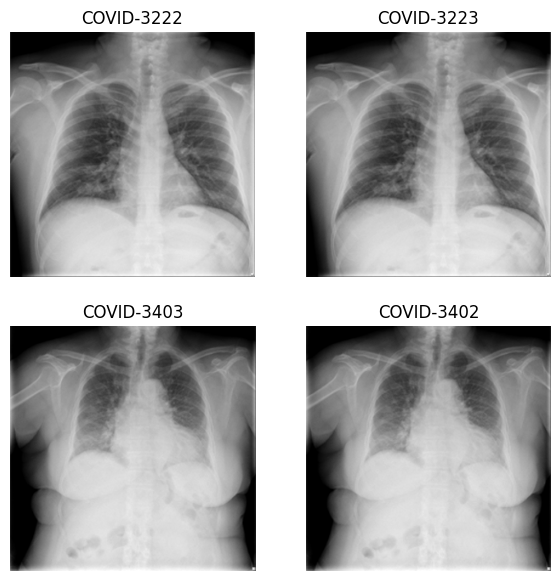

In [38]:
### ---- Checking the dataset for duplicates ---- ####

# Importing the data frame and display the first lines
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/df_stat_Anne.xlsx')
df.head()

# Check the dataframe for duplicates (rows that have the same values for their descriptive stats)
num_of_putative_duplicates = df.duplicated(subset = ['Count', 'Mean', 'Std_dev', 'Min', 'Max', 'Median', 'Q25', 'Q75', 'Skewness', 'Kurtosis']).sum()
print(f'Number of putative duplicates identified by all stats: {num_of_putative_duplicates}')

# Check wether mean and std are sufficient to identify duplicates
num_of_putative_duplicates = df.duplicated(subset = ['Std_dev', 'Mean']).sum()
print(f'Number of putative duplicates identified by mean and std: {num_of_putative_duplicates}')

# Create a dataframe of putative duplicates and display its shape and first rows
putative_duplicates = df.duplicated(subset = ['Count', 'Mean', 'Std_dev', 'Min', 'Max', 'Median', 'Q25', 'Q75', 'Skewness', 'Kurtosis'], keep=False)
duplicate_df = df[putative_duplicates]
duplicate_df.head()

# Check whether the images are duplicates

# Create variables that store the image indexes of equal image pairs
a_index = []
b_index = []

# Loop through the duplicate df to identify image pairs
for a in range(len(duplicate_df)):
  for b in range(a+1,len(duplicate_df)):
    # Check if the mean and std are equal (sufficient to identify the 59 putative duplicates)
    if (duplicate_df.iloc[a]['Mean'] == duplicate_df.iloc[b]['Mean']) and (duplicate_df.iloc[a]['Std_dev'] == duplicate_df.iloc[b]['Std_dev']) and (a!=b):
      # Get image path
      img_path1 = duplicate_df.iloc[a]['Img_path']
      img_path2 = duplicate_df.iloc[b]['Img_path']
      # Read images
      img1 = cv2.imread(img_path1, cv2.IMREAD_GRAYSCALE)
      img2 = cv2.imread(img_path2, cv2.IMREAD_GRAYSCALE)
      # Compare arrays
      if np.array_equal(img1, img2):
        print(f"Are {a} and {b} equal: {np.array_equal(img1, img2)}")
        a_index.append(a)
        b_index.append(b)

# Display two example images of duplicates

# Read two image pairs
img1 = cv2.imread(duplicate_df.iloc[a_index[0]]['Img_path'], cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(duplicate_df.iloc[b_index[0]]['Img_path'], cv2.IMREAD_GRAYSCALE)
img3 = cv2.imread(duplicate_df.iloc[a_index[10]]['Img_path'], cv2.IMREAD_GRAYSCALE)
img4 = cv2.imread(duplicate_df.iloc[b_index[10]]['Img_path'], cv2.IMREAD_GRAYSCALE)

# Display example images of duplicates
fig, axs = plt.subplots(2, 2, figsize=(7, 7))
axs[0,0].imshow(img1, cmap='gray')
axs[0,1].imshow(img2, cmap='gray')
axs[1,0].imshow(img3, cmap='gray')
axs[1,1].imshow(img4, cmap='gray')
axs[0,0].axis('off')
axs[0,1].axis('off')
axs[1,0].axis('off')
axs[1,1].axis('off')
axs[0,0].set_title(f"{duplicate_df.iloc[a_index[0]]['Name']}")
axs[0,1].set_title(f"{duplicate_df.iloc[b_index[0]]['Name']}")
axs[1,0].set_title(f"{duplicate_df.iloc[a_index[10]]['Name']}")
axs[1,1].set_title(f"{duplicate_df.iloc[b_index[10]]['Name']}")

# Save image as .png
plt.savefig('007_AnneAst_Duplicates_examples.png', bbox_inches = 'tight')